In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import zipfile
import io


path = '/content/drive/MyDrive/Neural Net/problem set 2.zip'

# Open the zip file and read the specific CSV file 'bank-data/bank-full.csv'
with zipfile.ZipFile(path, 'r') as z:
    with z.open('bank-data/bank-full.csv') as f:
        df = pd.read_csv(io.TextIOWrapper(f), sep=';')

le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])


X = df.drop('y', axis=1)
y = df['y']

In [8]:
import pandas as pd
import zipfile
import io

zip_file_path = '/content/drive/MyDrive/Neural Net/problem set 2.zip'

# Open the zip file and read the specific CSV file 'bank-data/bank-full.csv'
with zipfile.ZipFile(zip_file_path, 'r') as z:
    with z.open('bank-data/bank-full.csv') as f:
        df = pd.read_csv(io.TextIOWrapper(f), sep=';')

print(df.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

print("Encoding Completed!")

Encoding Completed!


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report


X = df.drop('y', axis=1)
y = df['y']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = LogisticRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 88.79%

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.98      0.94      7952
           1       0.60      0.22      0.32      1091

    accuracy                           0.89      9043
   macro avg       0.75      0.60      0.63      9043
weighted avg       0.86      0.89      0.86      9043



In [11]:

model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.80      0.88      7952
           1       0.36      0.81      0.50      1091

    accuracy                           0.80      9043
   macro avg       0.66      0.81      0.69      9043
weighted avg       0.89      0.80      0.83      9043



In [12]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}


grid_search = GridSearchCV(LogisticRegression(class_weight='balanced', max_iter=1000),
                           param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best))

Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
              precision    recall  f1-score   support

           0       0.97      0.80      0.88      7952
           1       0.36      0.81      0.50      1091

    accuracy                           0.80      9043
   macro avg       0.66      0.81      0.69      9043
weighted avg       0.89      0.80      0.83      9043



In [13]:

y_scores = best_model.predict_proba(X_test)[:, 1]


y_pred_tuned = (y_scores >= 0.6).astype(int)

print("--- Result after Threshold Tuning (0.6) ---")
print(classification_report(y_test, y_pred_tuned))

--- Result after Threshold Tuning (0.6) ---
              precision    recall  f1-score   support

           0       0.95      0.86      0.91      7952
           1       0.41      0.68      0.51      1091

    accuracy                           0.84      9043
   macro avg       0.68      0.77      0.71      9043
weighted avg       0.89      0.84      0.86      9043



In [14]:

import numpy as np

coefficients = best_model.coef_[0]
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(coefficients)})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))

      Feature  Importance
11   duration    1.339182
8     contact    0.613746
6     housing    0.546292
12   campaign    0.418301
14   previous    0.347804
13      pdays    0.300198
7        loan    0.263774
15   poutcome    0.181232
3   education    0.162195
2     marital    0.133226


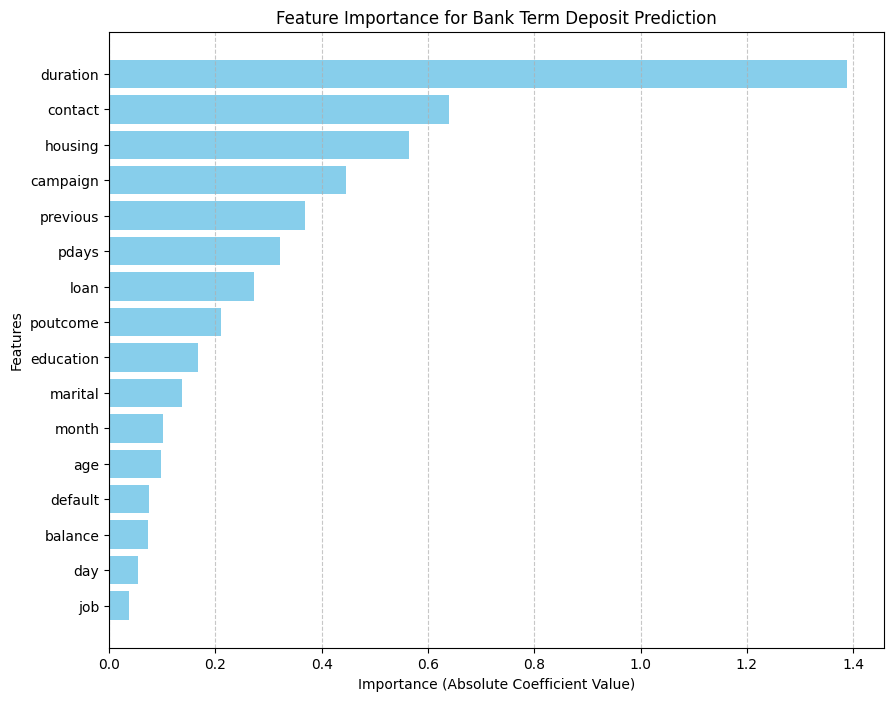

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


feature_names = X.columns
coefficients = model.coef_[0]


feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': np.abs(coefficients)})


feature_importance = feature_importance.sort_values(by='Importance', ascending=True)


plt.figure(figsize=(10, 8))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='skyblue')
plt.xlabel('Importance (Absolute Coefficient Value)')
plt.ylabel('Features')
plt.title('Feature Importance for Bank Term Deposit Prediction')
plt.grid(axis='x', linestyle='--', alpha=0.7)


plt.show()

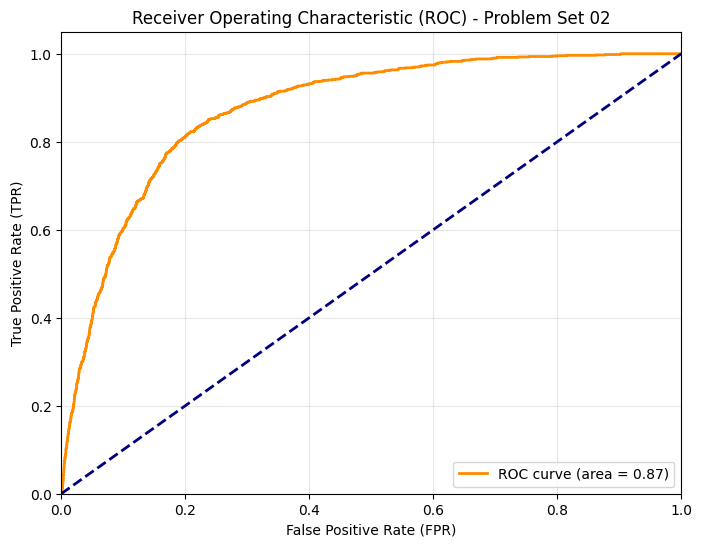

In [16]:
from sklearn.metrics import roc_curve, auc


y_probs = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)


plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) - Problem Set 02')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()